In [ ]:
# 데이터 분석 및 시각화에 필요한 기본 라이브러리들을 불러옵니다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn 라이브러리에서 필요한 모듈들을 불러옵니다.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# TensorFlow Keras 라이브러리를 불러옵니다.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

1.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

2.

In [ ]:
loan_df = pd.read_csv('8_loan_approval.csv')

loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   employment_type      1740 non-null   object 
 1   annual_income        1744 non-null   float64
 2   credit_score         1738 non-null   float64
 3   loan_purpose         1743 non-null   object 
 4   loan_amount          1758 non-null   float64
 5   dti                  1753 non-null   float64
 6   years_employed       1745 non-null   float64
 7   home_ownership       1728 non-null   object 
 8   delinquency_history  1737 non-null   object 
 9   loan_status          1800 non-null   int64  
dtypes: float64(5), int64(1), object(4)
memory usage: 140.8+ KB


3.

<Axes: xlabel='loan_status', ylabel='credit_score'>

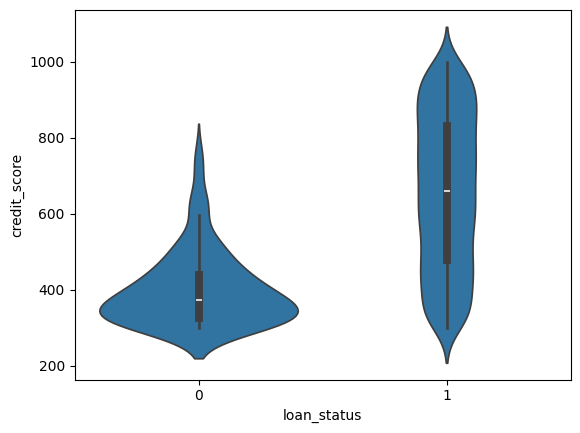

In [ ]:
sns.violinplot(data=loan_df, x='loan_status', y='credit_score')

4.

In [ ]:
pd.crosstab(loan_df['home_ownership'], loan_df['loan_status'], normalize='index')

loan_status,0,1
home_ownership,,
월세,0.065744,0.934256
자가,0.041528,0.958472
전세,0.034672,0.965328


5.

In [ ]:
loan_df.groupby(['employment_type'])[['annual_income', 'loan_amount']].mean()

,annual_income,loan_amount
employment_type,,
계약직,10451.086207,5082.815864
무직,11330.117647,5047.351190
자영업,10750.673529,5089.622478
정규직,11139.076087,5127.108173


6.

In [ ]:
loan_pre = loan_df.copy()

loan_pre['annual_income'].fillna(loan_pre['annual_income'].median(), inplace=True)
loan_pre['credit_score'].fillna(loan_pre['credit_score'].median(), inplace=True)
loan_pre['loan_amount'].fillna(loan_pre['loan_amount'].median(), inplace=True)
loan_pre['dti'].fillna(loan_pre['dti'].median(), inplace=True)
loan_pre['years_employed'].fillna(loan_pre['years_employed'].median(), inplace=True)

loan_pre['employment_type'].fillna(loan_pre['employment_type'].mode()[0], inplace=True)
loan_pre['loan_purpose'].fillna(loan_pre['loan_purpose'].mode()[0], inplace=True)
loan_pre['home_ownership'].fillna(loan_pre['home_ownership'].mode()[0], inplace=True)
loan_pre['delinquency_history'].fillna(loan_pre['delinquency_history'].mode()[0], inplace=True)

/tmp/ipykernel_901/3128614846.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  loan_pre['annual_income'].fillna(loan_pre['annual_income'].median(), inplace=True)
/tmp/ipykernel_901/3128614846.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

7.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

loan_pre['home_ownership'] = le.fit_transform(loan_pre['home_ownership'])
loan_pre['delinquency_history'] = le.fit_transform(loan_pre['delinquency_history'])

loan_pre = pd.get_dummies(data=loan_pre, columns=['employment_type', 'loan_purpose'])

8.

In [ ]:
X = loan_pre.drop(columns=['loan_status'])
y = loan_pre['loan_status']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=2024, stratify=y)

9.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

10.

In [ ]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(random_state=2024)
model_lr.fit(X_train_scaled, y_train)

LogisticRegression(random_state=2024)

11.

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

model_ada = AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=2024)

model_ada.fit(X_train_scaled, y_train)

ada_pred = model_ada.predict(X_valid_scaled)

12.

LR
F1 : 0.996116504854369
ADA
F1: 0.991321118611379


<Axes: >

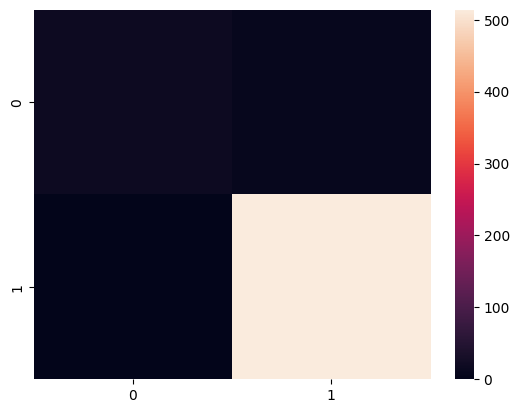

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix

lr_pred = model_lr.predict(X_valid_scaled)

print('LR')
print('F1 :', f1_score(y_valid, lr_pred))

print('ADA')
print('F1:', f1_score(y_valid, ada_pred))

sns.heatmap(confusion_matrix(y_valid, ada_pred))

13.

In [ ]:
model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_scaled, y_train, epochs=20, batch_size=64, validation_data=(X_valid_scaled, y_valid))

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7373 - loss: 0.5683 - val_accuracy: 0.8296 - val_loss: 0.5024
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8786 - loss: 0.4609 - val_accuracy: 0.9037 - val_loss: 0.4051
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9238 - loss: 0.3745 - val_accuracy: 0.9278 - val_loss: 0.3248
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9437 - loss: 0.3055 - val_accuracy: 0.9444 - val_loss: 0.2637
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9524 - loss: 0.2540 - val_accuracy: 0.9481 - val_loss: 0.2213
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9532 - loss: 0.2191 - val_accuracy: 0.9500 - val_loss: 0.1916
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9532 - loss: 0.1941 - val_accuracy: 0.9519 - val_loss: 0.1721
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9532 - loss: 0.1770 - val_accuracy: 0.9519 - val_loss

14.

In [ ]:
# 아래 코드를 실행하여 시뮬레이션용 데이터를 생성하세요.
new_applicant_data = np.array([[10000, 750, 5000, 150, 5, 1, 12, 0, 0, 0, 1, 0, 0, 0, 1]])

In [ ]:
new_applicant_data_scaled = scaler.transform(new_applicant_data)

predicted_approval_prob = model.predict(new_applicant_data_scaled)

print(predicted_approval_prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
[[0.9999989]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
